# Worked Example
                
### Task 1: Theory of Regression 
         
Consider simple linear regression of the form

$$y=mx + c$$

to best fit some data. We do this by minimising the sum of squared errors (SSE):
                
a) Error Definition

In the context of a single data point $(x_{i}, y_{i})$, the error (also known as the residual $\epsilon_i$) is the vertical distance between the observed value $y_i$ and the value predicted by the regression line $y = mx_i + c$
$$\epsilon_i = y_i - (mx_i + c)$$

b) SSE Expression

The Sum of Squared Errors (SSE) for $n$ data points is the sum of the squares of these residuals:$$SSE = \sum_{i=1}^{n} (y_i - (mx_i + c))^2$$

c) Rationale for Squaring Errors

We square the errors instead of simply summing them for two primary reasons:

- Directionality: Errors can be positive or negative. A simple sum would allow large positive and negative errors to cancel each other out, potentially resulting in a "total error" of zero for a very poor fit.

- Penalty: Squaring gives more weight to larger outliers, ensuring the optimization process prioritizes reducing large deviations.

d) Finding Optimal Parameters

Optimal parameters $m$ and $c$ are found by minimizing the SSE. In matrix and vector notation, this is achieved by solving the normal equations
$$\beta = (A^T A)^{-1} A^T Y$$
where $\beta$ contains the coefficients $[c, m]^T$.

Alternatively, this can be solved using the pseudo-inverse $A^+$
$$\beta = A^+ Y = (A^T A)^{-1} A^T Y$$

e) Quality Estimation

- Coefficient of Determination ($R^2$): Measures the proportion of variance in $y$ explained by $x$.
- Standard Error of the Estimate (SEE, $s_y$): Measures the average distance that the observed values fall from the regression line.
- Confidence bands (see below)








### Task 2: Practical Regression 

A student measures the extension of a spring ($y$) under different masses ($x$). The data is as follows:

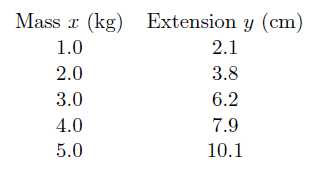

a) Using the provided spring extension data:
Slope ($m$): $2.01$ cm/kg and Intercept ($c$): $-0.01$ cm

Calculations:
- $n = 5$
- $\bar{x} = 3.0$ kg
- $\bar{y} = 6.02$ cm
- $SS_x = \sum(x_i - \bar{x})^2 = (1-3)^2 + (2-3)^2 + (3-3)^2 + (4-3)^2 + (5-3)^2 = 10$ kg$^2$9.
- $SS_{xy} = \sum(x_i - \bar{x})(y_i - \bar{y}) = 20.1$ kg$\cdot$cm.

Results:
- Slope ($m$): $m = \frac{SS_{xy}}{SS_x} = \frac{20.1}{10} = \mathbf{2.01 \text{ cm/kg}}$.
- Intercept ($c$): $c = \bar{y} - m\bar{x} = 6.02 - (2.01 \times 3.0) = \mathbf{-0.01 \text{ cm}}$.



b) Coefficient of Determination ($R^{2}$) Value: 

$R^2$ is calculated as $1 - \frac{SSE}{SST}$. $R^2 \approx 0.997$. Meaning: $99.7\%$ of the variance in spring extension is explained by the mass, indicating an excellent fit.
                                                    
c) Standard Error ($S_{y}$) Formula: 

$$S_y = \sqrt{\frac{\sum (y_i - \hat{y}_i)^2}{N-2}}= \sqrt{\frac{SSE}{N-2}}$$

Normalization: We use $N-2$ because two degrees of freedom are lost to the estimation of $m$ and $c$.

Unit: The standard error has a unit (cm).

d) Plot the data with error bars (see below)

e) 95% Confidence Interval for $m$

Using $S_{m}=\frac{S_{y}}{\sqrt{SS_{x}}}$:

Standard Error of Slope ($S_m$): $\approx 0.0597$ cm/kg

95% Interval: Calculated using the t-distribution (value $t*$) for $N-2=3$ degrees of freedom gives  $t_{0.025, 3} \approx 3.182$. Thus the result is: 
$$\text{CI} = m \pm (t^* \cdot S_m) = 2.01 \pm (3.182 \cdot 0.0597)$$ 
or an inteval $[1.82, 2.20]$ cm/kg.
                                                                            
f) Outlier Analysis

A new point $(6.0, 25.0)$ would drastically increase the slope and decrease the $R^2$ This point should likely not be added. A reasonable criterion is checking if the residual of the new point exceeds $3S_y$ (the three-sigma rule) or using Chauvenet's criterion to identify it as an outlier.                                                                           
                                                                            
                                                                            

                                                                                                    


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [3]:
# Task 3.2: Regression Data
x = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
y = np.array([2.1, 3.8, 6.2, 7.9, 10.1])

# Computations using stats.linregress
m, c, r_v, p_v, sm = stats.linregress(x, y)
sy = np.sqrt(np.sum((y - (m*x + c))**2) / (len(x)-2))
print("stats toolbox",m,c,r_v**2,sm,sy)

SSE = np.sum((y - (m*x + c))**2)
ymean = np.sum(y)/len(x)
SST = np.sum( (y-ymean)**2)
R2 = 1-SSE/SST
print('R2=',R2)
N=len(x)
k=2
print('adjusted R2=',1-(1-R2)*(N-1)/(N-k))
print('Standard error in y=',sy)
SSx = np.sum((x-np.mean(x))**2)
print('S_m =',sy/np.sqrt(SSx))

# Computations using pseudo-inverse
A = np.vstack([np.ones(len(x)), x]).T 
A_plus = np.linalg.pinv(A) 
beta = A_plus @ y 
intercept_c = beta[0]
slope_m = beta[1]
print("beta = ",beta)

print('t values (two-sided, 5% CI, 3 dofs): ',stats.t.ppf(0.975, 3))

stats toolbox 2.0100000000000002 -0.010000000000000675 0.9973585464599587 0.05972157622389449 0.18885620632287084
R2= 0.9973585464599585
adjusted R2= 0.9964780619466113
Standard error in y= 0.18885620632287084
S_m = 0.05972157622389646
beta =  [-0.01  2.01]
t values (two-sided, 5% CI, 3 dofs):  3.1824463052837078


There are various ways to show the accuracy of the fit using error bars or error bands:
- error bars around the data points: This is typically used for measurement uncertainty, so perhaps not the best way in the current setting.
- we have calcuated the standard deviation of the data points from the regressed line $s_y$, also called "Standard Error of the Estimate (SEE)". This is technically not a confidence interval, but rather a way to express the variation (noise) of the data.
$$s_y = \sqrt{\frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{n - 2}}$$
- The confidence interval of the regression would be smallest in the centre. There is also the prediction interval, which is slightly larger.
$$y = \hat{y} \pm t_{\alpha/2, n-2} \cdot s_y \sqrt{\frac{1}{n} + \frac{(x_0 - \bar{x})^2}{\sum_{i=1}^{n} (x_i - \bar{x})^2}}$$

- There is also the prediction interval, which is slightly larger:
$$y = \hat{y} \pm t_{\alpha/2, n-2} \cdot s_y \sqrt{1+\frac{1}{n} + \frac{(x_0 - \bar{x})^2}{\sum_{i=1}^{n} (x_i - \bar{x})^2}}$$


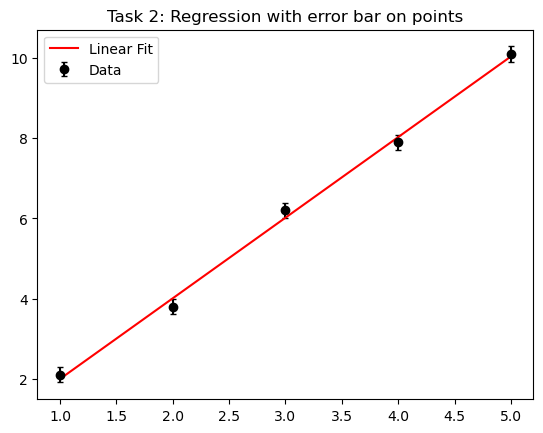

In [4]:
# Visualization with error bars corresponding to the standard deviation Sy
plt.figure()
plt.errorbar(x, y, yerr=sy, fmt='ko', label='Data',capsize=2)
plt.plot(x, m*x+c, 'r', label='Linear Fit')
plt.title('Task 2: Regression with error bar on points')
plt.legend()
plt.show()

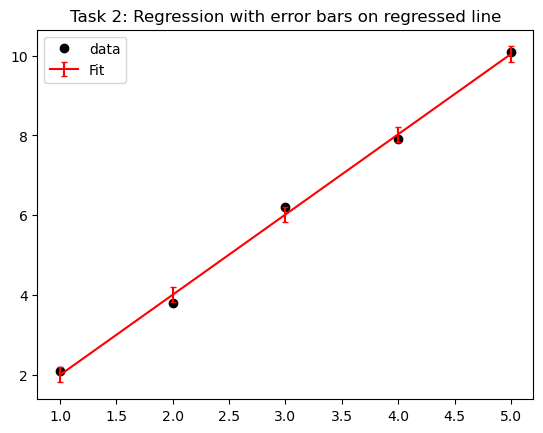

In [5]:
# Visualization with error bars corresponding to the standard deviation Sy
plt.figure()
plt.plot(x, y, 'ko',label='data')
plt.errorbar(x, m*x+c, yerr=sy,  color='r',label='Fit',capsize=2)
plt.title('Task 2: Regression with error bars on regressed line')
plt.legend()
plt.show()

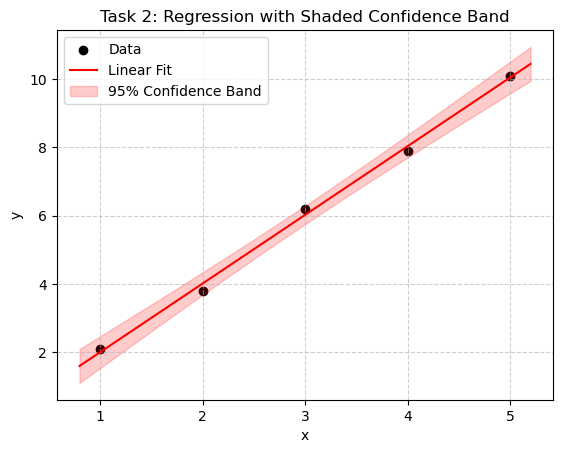

In [6]:
# Create a range of x values for the line and band
x_plot = np.linspace(0.8, 5.2, 100)
y_plot = m * x_plot + c

# The band width formula
n = len(x)
mean_x = np.mean(x)
sum_sq_x = np.sum((x - mean_x)**2)
t_val = stats.t.ppf(0.975, n-2) # t values for 5% confidence and two degrees of freedom less
conf_interval = t_val * sy * np.sqrt(1/n + (x_plot - mean_x)**2 / sum_sq_x)

# Plotting
plt.figure()
plt.scatter(x, y, color='black', label='Data')
plt.plot(x_plot, y_plot, color='red', label='Linear Fit')

# Fill the confidence band
plt.fill_between(x_plot, y_plot - conf_interval, y_plot + conf_interval, 
                 color='red', alpha=0.2, label='95% Confidence Band')

plt.title('Task 2: Regression with Shaded Confidence Band')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

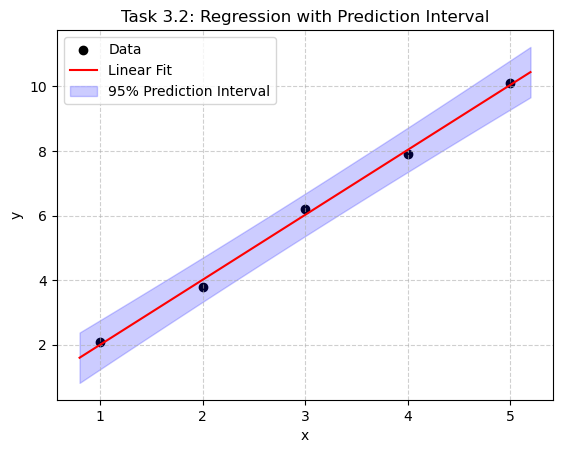

In [7]:
# Create a range of x values for the line and band
x_plot = np.linspace(0.8, 5.2, 100)
y_plot = m * x_plot + c

# The band width formula
n = len(x)
mean_x = np.mean(x)
sum_sq_x = np.sum((x - mean_x)**2)
t_val = stats.t.ppf(0.975, n-2) # t values for 5% confidence and two degrees of freedom less
conf_interval = t_val * sy * np.sqrt(1+1/n + (x_plot - mean_x)**2 / sum_sq_x)

# Plotting
plt.figure()
plt.scatter(x, y, color='black', label='Data')
plt.plot(x_plot, y_plot, color='red', label='Linear Fit')

# Fill the confidence band
plt.fill_between(x_plot, y_plot - conf_interval, y_plot + conf_interval, 
                 color='blue', alpha=0.2, label='95% Prediction Interval')

plt.title('Task 3.2: Regression with Prediction Interval')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

stats toolbox 3.86 -4.326666666666666 0.7652968081203377 1.0688133161417404 4.4711668872156105


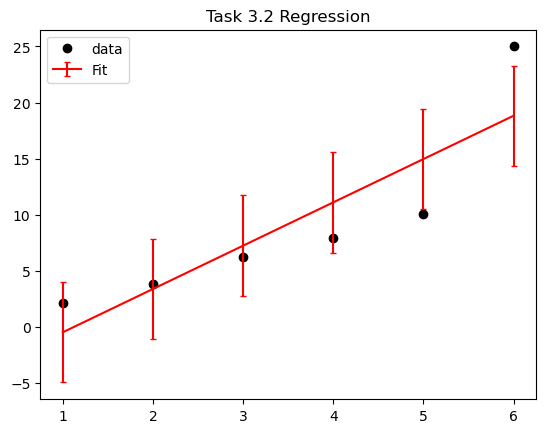

In [8]:
# Task 3.2: Regression Data
x = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0])
y = np.array([2.1, 3.8, 6.2, 7.9, 10.1, 25.0])

# Computations using stats.linregress
m, c, r_v, p_v, sm = stats.linregress(x, y)
sy = np.sqrt(np.sum((y - (m*x + c))**2) / (len(x)-2))
print("stats toolbox",m,c,r_v**2,sm,sy)

# Visualization
plt.figure()
plt.plot(x, y, 'ko',label='data')
plt.errorbar(x, m*x+c, yerr=sy,  color='r',label='Fit',capsize=2)
plt.title('Task 3.2 Regression')
plt.legend()
plt.show()

In [9]:
# Let's apply Chauvenet's criterion
# P = (n-1/2)/n = 1/(2n)
# Z is the standardised data

from scipy import special

def apply_chauvenet(data):
    """
    Applies Chauvenet's criterion to a 1D numpy array.
    Returns a boolean mask where True indicates an outlier.
    """
    mu = np.mean(data)
    sigma = np.std(data)
    N = len(data)
    
    # Calculate the number of standard deviations from the mean
    z_scores = np.abs(data - mu) / sigma
    
    # Calculate the probability of a value being further from the mean 
    # (using the complementary error function)
    probabilities = special.erfc(z_scores / np.sqrt(2))
    
    # Chauvenet's criterion: N * P < 0.5 (or P < 1/(2N))
    P_value = (1.0 / (2 * N))
    is_outlier = probabilities < P_value
    
    return is_outlier, probabilities, P_value

# Apply criterion to the observed variable y
outliers, probs, P_value = apply_chauvenet(y)

# Results
print(f"Chauvenet's Criterion Results: Rejection probability = {P_value:<12.4f}")
print(f"{'Value (y)':<10} | {'Probability':<12} | {'Is Outlier?'}")
print("-" * 40)
for val, p, is_out in zip(y, probs, outliers):
    print(f"{val:<10.2f} | {p:<12.4f} | {is_out}")

# Filtered Data
clean_x = x[~outliers]
clean_y = y[~outliers]
print(f"\nCleaned Data y: {clean_y}")


Chauvenet's Criterion Results: Rejection probability = 0.0833      
Value (y)  | Probability  | Is Outlier?
----------------------------------------
2.10       | 0.3472       | False
3.80       | 0.4750       | False
6.20       | 0.6922       | False
7.90       | 0.8648       | False
10.10      | 0.9032       | False
25.00      | 0.0358       | True

Cleaned Data y: [ 2.1  3.8  6.2  7.9 10.1]
